In [168]:
from __future__ import annotations

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

from pathlib import Path
import sys

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Project import ----
# Assumption: notebook lives in project_root/notebooks/ so parents[0] is project_root.
# If your notebook is deeper, change parents[...] accordingly.
PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst  # noqa: E402

# Global reproducibility for synthetic data generation
GLOBAL_SEED = 11
rng = np.random.default_rng(GLOBAL_SEED)


# Case 1

## Functions

In [169]:
def gaussian_blob(y2d, x2d, y0, x0, sig_y=6.0, sig_x=10.0, amp=1.0):
    """
    2D Gaussian blob centered at (y0, x0) in Cartesian space.

    Important decision:
    - Cartesian coordinates use ordinary Euclidean distance.
    - No periodic wrapping is applied by default.
    """
    dy = y2d - float(y0)
    dx = x2d - float(x0)

    return amp * np.exp(-0.5 * (dy / sig_y) ** 2 - 0.5 * (dx / sig_x) ** 2)


def advect_centers(y0, x0, vy, vx, T):
    """
    Deterministic trajectory of the blob center in Cartesian space.

    Decision:
    - Constant velocity advection keeps the example interpretable.
    - You can later add time-varying velocity for a harder test.
    """
    centers = np.zeros((T, 2), dtype=float)
    y, x = float(y0), float(x0)

    for t in range(T):
        centers[t] = (y, x)
        y += float(vy)
        x += float(vx)

    return centers


def make_ar1_noise(shape, phi=0.8, sigma=0.1, rng=None, standardize=False):
    """
    Generate AR(1) noise in time independently at each grid point.

    Parameters
    ----------
    shape : tuple
        (T, NY, NX)
    phi : float
        AR(1) coefficient in time. Must satisfy |phi| < 1.
    sigma : float
        Innovation std.
    rng : np.random.Generator
    standardize : bool
        If True, standardize final field to mean 0 and std 1.

    Returns
    -------
    noise : np.ndarray
        AR(1) noise with shape (T, NY, NX)
    """
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    # stationary initial condition
    noise[0] = rng.normal(
        0.0,
        sigma / np.sqrt(1.0 - phi**2 + 1e-12),
        size=(NY, NX)
    ).astype(np.float32)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        noise[t] = phi * noise[t - 1] + eps

    if standardize:
        noise = (noise - noise.mean()) / (noise.std() + 1e-12)

    return noise


from scipy.ndimage import gaussian_filter


def make_spatiotemporal_ar1_noise(
    shape,
    phi=0.8,
    sigma=0.1,
    smooth_sigma_y=1.5,
    smooth_sigma_x=1.5,
    rng=None,
    standardize=False
):
    """
    AR(1) in time with spatially smoothed innovations.

    Important decision:
    - In Cartesian toy experiments we use non-periodic boundaries,
      so smoothing uses mode='nearest'.
    """
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    eps0 = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
    eps0 = gaussian_filter(
        eps0,
        sigma=(smooth_sigma_y, smooth_sigma_x),
        mode="nearest"
    )

    noise[0] = eps0 / np.sqrt(1.0 - phi**2 + 1e-12)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        eps = gaussian_filter(
            eps,
            sigma=(smooth_sigma_y, smooth_sigma_x),
            mode="nearest"
        )
        noise[t] = phi * noise[t - 1] + eps

    if standardize:
        noise = (noise - noise.mean()) / (noise.std() + 1e-12)

    return noise

In [170]:
def run_one_track(full_data, params, date_end):
    """
    Single Trace-ST run; returns centers (n_steps, 2) and parents.
    """
    out = tst.trajectory.run_track(
        full_data,
        params,
        date_end=date_end,
        return_debug=True,
        return_cluster_summaries=False,
    )

    centers = np.asarray(out["centers"], dtype=float)
    parents = np.asarray(out["parents"], dtype=int)

    return centers, parents, out

## Create data

In [171]:
# --- Time axis ---
T = 40
time = pd.date_range("2001-01-01", periods=T, freq="D")  # arbitrary, deterministic

# --- Spatial grid (Cartesian) ---
Y_MIN, Y_MAX = 0, 200
X_MIN, X_MAX = 0, 200

NY = 121
NX = 241

ys = np.linspace(Y_MIN, Y_MAX, NY)
xs = np.linspace(X_MIN, X_MAX, NX)

x2d, y2d = np.meshgrid(xs, ys)

print("Grid:", "NY=", NY, "NX=", NX, "x range=", (xs.min(), xs.max()))


# ------------------------------------------------------------
# Toy case: three parent blobs in the same A field
# Higher temporal resolution, same large-scale behavior
# ------------------------------------------------------------

import copy
import numpy as np

def linear_centers_to_event(event_y, event_x, vy, vx, T):
    """
    Build a linear trajectory whose final point is (event_y, event_x).
    """
    centers = np.zeros((T, 2), dtype=float)
    centers[-1] = (event_y, event_x)

    for t in range(T - 2, -1, -1):
        centers[t, 0] = centers[t + 1, 0] - vy
        centers[t, 1] = centers[t + 1, 1] - vx

    return centers


def bezier_centers(start, control1, control2, end, T):
    """
    Smooth curved trajectory using a cubic Bezier curve.
    All points are given as (y, x).
    """
    u = np.linspace(0.0, 1.0, T)
    centers = np.zeros((T, 2), dtype=float)

    p0 = np.asarray(start, dtype=float)
    p1 = np.asarray(control1, dtype=float)
    p2 = np.asarray(control2, dtype=float)
    p3 = np.asarray(end, dtype=float)

    for i, s in enumerate(u):
        centers[i] = (
            (1 - s) ** 3 * p0
            + 3 * (1 - s) ** 2 * s * p1
            + 3 * (1 - s) * s ** 2 * p2
            + s ** 3 * p3
        )

    return centers


# ------------------------------------------------------------
# Shared field parameters
# ------------------------------------------------------------
sig_y = 10.0
sig_x = 10.0
amp = 1.0

phi_A = 0.8
sigma_A = 0.1

beta_AB = 0.8
phi_B = 0.8
sigma_B = 0.1

clip_to_positive = True
clip_to_positive_B = True

# ------------------------------------------------------------
# Define the 3 true trajectories
# Everything moved 75 units left so all paths fit inside the domain
# ------------------------------------------------------------

track_specs = [
    dict(
        name="Track 1",
        event=(100.0, 50.0),
        centers=bezier_centers(
            start=(50.0, 10.0),
            control1=(70.0, 40.0),
            control2=(80.0, 55.0),
            end=(100.0, 50.0),
            T=T,
        ),
        amp=1.0,
    ),

    dict(
        name="Track 2",
        event=(110.0, 105.0),
        centers=bezier_centers(
            start=(160.0, 60.0),
            control1=(150.0, 70.0),
            control2=(130.0, 130.0),
            end=(110.0, 105.0),
            T=T,
        ),
        amp=1.0,
    ),

    dict(
        name="Track 3",
        event=(70.0, 100.0),
        centers=linear_centers_to_event(
            event_y=70.0,
            event_x=100.0,
            vy=(70.0 - 36.0) / (T - 1),
            vx=(100.0 - 168.0) / (T - 1),
            T=T,
        ),
        amp=1.0,
    ),
]

for spec in track_specs:
    c = spec["centers"]
    print(
        f'{spec["name"]}: start={tuple(np.round(c[0], 2))}, '
        f'end={tuple(np.round(c[-1], 2))}'
    )


# ------------------------------------------------------------
# Build clean parent field A as the sum of the 3 blobs
# ------------------------------------------------------------
A_clean = np.zeros((T, NY, NX), dtype=np.float32)

for spec in track_specs:
    centers = spec["centers"]
    amp_i = spec.get("amp", amp)

    for t in range(T):
        A_clean[t] += gaussian_blob(
            y2d,
            x2d,
            y0=centers[t, 0],
            x0=centers[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_i,
        ).astype(np.float32)

# ------------------------------------------------------------
# Add spatiotemporally autocorrelated noise to A
# ------------------------------------------------------------
rng_A = np.random.default_rng(GLOBAL_SEED)

noise_A = make_spatiotemporal_ar1_noise(
    A_clean.shape,
    phi=phi_A,
    sigma=sigma_A,
    rng=rng_A,
)

A = A_clean + noise_A

if clip_to_positive:
    A = np.clip(A, 0.0, None)

# ------------------------------------------------------------
# Build child field B from lagged A plus its own persistent noise
# ------------------------------------------------------------
rng_B = np.random.default_rng(GLOBAL_SEED + 1)

noise_B = make_spatiotemporal_ar1_noise(
    A.shape,
    phi=0.8,
    sigma=sigma_B,
    rng=rng_B,
)

B = np.zeros_like(A, dtype=np.float32)
B[0] = noise_B[0]

for t in range(1, T):
    B[t] = phi_B * B[t - 1] + beta_AB * A[t - 1] + noise_B[t]

if clip_to_positive_B:
    B = np.clip(B, 0.0, None)

print(
    "Raw Corr(A[t-1], B[t]) =",
    float(np.corrcoef(A[:-1].ravel(), B[1:].ravel())[0, 1])
)

Grid: NY= 121 NX= 241 x range= (0.0, 200.0)
Track 1: start=(50.0, 10.0), end=(100.0, 50.0)
Track 2: start=(160.0, 60.0), end=(110.0, 105.0)
Track 3: start=(36.0, 168.0), end=(70.0, 100.0)
Raw Corr(A[t-1], B[t]) = 0.8822109442587748


# load runs

In [172]:
# # CREATED WITH NOTEBOOK

# # --- core ---
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # --- plotting style ---
# plt.rcParams["figure.dpi"] = 120

# # --- paths ---
# OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic")  # CHANGE if needed
# tag = "univariate_search_test_n100_all"  # CHANGE if needed

# # --- load data ---
# df_long = pd.read_csv(OUTDIR / f"{tag}_long.csv")
# df_trial = pd.read_csv(OUTDIR / f"{tag}_trial.csv")
# df_traj = pd.read_pickle(OUTDIR / f"{tag}_traj.pkl")

# print("Loaded:")
# print("df_long :", df_long.shape)
# print("df_trial:", df_trial.shape)
# print("df_traj :", df_traj.shape)

# df_trial.head()

In [173]:
## CREATED WITH .PY

# --- core ---
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- plotting style ---
plt.rcParams["figure.dpi"] = 120

# --- paths ---
OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/univariate_v0")  # CHANGE if needed

# -----------------------------------------------------------------------------
# helpers
# -----------------------------------------------------------------------------
def _load_jsonl(path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def _maybe_parse_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return None
        try:
            return json.loads(x)
        except Exception:
            try:
                return ast.literal_eval(x)
            except Exception:
                return x
    return x

# -----------------------------------------------------------------------------
# load outputs
# -----------------------------------------------------------------------------
jobs_jsonl = OUTDIR / "results_jobs.jsonl"
tracks_jsonl = OUTDIR / "results_tracks.jsonl"

jobs_csv = OUTDIR / "results_jobs_final.csv"
if not jobs_csv.exists():
    jobs_csv = OUTDIR / "results_jobs_snapshot.csv"

tracks_csv = OUTDIR / "results_tracks_final.csv"
if not tracks_csv.exists():
    tracks_csv = OUTDIR / "results_tracks_snapshot.csv"

# Prefer JSONL for tracks because it preserves nested trajectory lists cleanly
if jobs_jsonl.exists():
    jobs_raw = _load_jsonl(jobs_jsonl)
else:
    jobs_raw = pd.read_csv(jobs_csv)

if tracks_jsonl.exists():
    tracks_raw = _load_jsonl(tracks_jsonl)
else:
    tracks_raw = pd.read_csv(tracks_csv)
    if "centers_raw" in tracks_raw.columns:
        tracks_raw["centers_raw"] = tracks_raw["centers_raw"].apply(_maybe_parse_list)
    if "parents_raw" in tracks_raw.columns:
        tracks_raw["parents_raw"] = tracks_raw["parents_raw"].apply(_maybe_parse_list)

# -----------------------------------------------------------------------------
# standardize names / expected columns
# -----------------------------------------------------------------------------
param_cols = [
    "timewindow", "box_size", "radius", "eps_dbscan", "min_samples_dbscan",
    "score_mode", "winner_summary", "alpha", "prefer_sign", "prob_rule",
    "beta_softmax", "lambda_a", "l1_ratio", "dependence_threshold",
    "max_iter", "fit_intercept", "refit_ridge", "ridge_alpha",
    "pc_alpha", "graph_p_threshold", "cond_ind_test_name", "fdr_method"
]

track_metric_cols = [
    "raw_len", "failed", "mean_distance", "origin_distance", "event_distance",
    "path_length", "net_displacement", "mean_step", "stagnant_frac",
    "parent2_frac"
]

for c in param_cols:
    if c not in jobs_raw.columns:
        jobs_raw[c] = np.nan
    if c not in tracks_raw.columns:
        tracks_raw[c] = np.nan

# if some older run still had track_id, standardize to track_idx
if "track_id" in tracks_raw.columns and "track_idx" not in tracks_raw.columns:
    tracks_raw = tracks_raw.rename(columns={"track_id": "track_idx"})

# -----------------------------------------------------------------------------
# df_long
# -----------------------------------------------------------------------------
required_df_long = [
    "method", "trial_id", "track_name", "track_idx", "event_y", "event_x",
    "raw_len", "failed", "mean_distance", "origin_distance",
    "event_distance", "path_length", "net_displacement", "mean_step",
    "stagnant_frac", "parent2_frac", "elapsed_sec"
] + param_cols

for c in required_df_long:
    if c not in tracks_raw.columns:
        tracks_raw[c] = np.nan

df_long = tracks_raw[required_df_long].copy()

# -----------------------------------------------------------------------------
# df_trial
# -----------------------------------------------------------------------------
job_base = jobs_raw.copy()

rename_job_to_old = {
    "score_mean_distance": "mean_distance",
    "score_origin_distance": "mean_origin_distance",
    "score_event_distance": "mean_event_distance",
    "score_path_length": "mean_path_length",
    "score_net_displacement": "mean_net_displacement",
    "score_stagnant_frac": "mean_stagnant_frac",
    "score_parent2_frac": "mean_parent2_frac",
}
for src, dst in rename_job_to_old.items():
    if src in job_base.columns:
        job_base = job_base.rename(columns={src: dst})

# keep only successful runs, like old analyses usually expect
if "ok" in job_base.columns:
    job_base = job_base[job_base["ok"] == 1].copy()

agg = (
    tracks_raw.groupby(["method", "trial_id"], as_index=False)
    .agg(
        n_tracks=("track_idx", "size"),
        n_failed=("failed", "sum"),
        mean_raw_len=("raw_len", "mean"),
        min_raw_len=("raw_len", "min"),
        mean_distance=("mean_distance", "mean"),
        max_distance=("mean_distance", "max"),
        mean_origin_distance=("origin_distance", "mean"),
        mean_event_distance=("event_distance", "mean"),
        mean_path_length=("path_length", "mean"),
        mean_net_displacement=("net_displacement", "mean"),
        mean_step=("mean_step", "mean"),
        mean_stagnant_frac=("stagnant_frac", "mean"),
        mean_parent2_frac=("parent2_frac", "mean"),
    )
)

wide_parts = []
for tidx in [1, 2, 3]:
    tmp = tracks_raw[tracks_raw["track_idx"] == tidx][["method", "trial_id"] + track_metric_cols].copy()
    tmp = tmp.rename(columns={m: f"track{tidx}_{m}" for m in track_metric_cols})
    wide_parts.append(tmp)

wide = wide_parts[0]
for tmp in wide_parts[1:]:
    wide = wide.merge(tmp, on=["method", "trial_id"], how="outer")

job_keep_cols = ["method", "trial_id", "elapsed_sec"] + param_cols
for c in job_keep_cols:
    if c not in job_base.columns:
        job_base[c] = np.nan

job_base = job_base[job_keep_cols].drop_duplicates(subset=["method", "trial_id"]).copy()

df_trial = (
    job_base
    .merge(agg, on=["method", "trial_id"], how="left")
    .merge(wide, on=["method", "trial_id"], how="left")
)

required_df_trial = [
    "method", "trial_id", "n_tracks", "n_failed", "mean_raw_len",
    "min_raw_len", "mean_distance", "max_distance", "mean_origin_distance",
    "mean_event_distance", "mean_path_length", "mean_net_displacement",
    "mean_step", "mean_stagnant_frac", "mean_parent2_frac", "elapsed_sec"
] + param_cols + [
    "track1_raw_len", "track1_failed", "track1_mean_distance",
    "track1_origin_distance", "track1_event_distance", "track1_path_length",
    "track1_net_displacement", "track1_mean_step", "track1_stagnant_frac",
    "track1_parent2_frac",
    "track2_raw_len", "track2_failed", "track2_mean_distance",
    "track2_origin_distance", "track2_event_distance", "track2_path_length",
    "track2_net_displacement", "track2_mean_step", "track2_stagnant_frac",
    "track2_parent2_frac",
    "track3_raw_len", "track3_failed", "track3_mean_distance",
    "track3_origin_distance", "track3_event_distance", "track3_path_length",
    "track3_net_displacement", "track3_mean_step", "track3_stagnant_frac",
    "track3_parent2_frac",
]

for c in required_df_trial:
    if c not in df_trial.columns:
        df_trial[c] = np.nan

df_trial = df_trial[required_df_trial].copy()

# optional: sort trials the same way the script ranks them
sort_cols = [c for c in ["mean_distance", "mean_origin_distance", "mean_event_distance"] if c in df_trial.columns]
if sort_cols:
    df_trial = df_trial.sort_values(sort_cols, ascending=True).reset_index(drop=True)

# -----------------------------------------------------------------------------
# df_traj
# -----------------------------------------------------------------------------
required_df_traj = [
    "method", "trial_id", "track_name", "track_idx", "event_y", "event_x",
    "centers_raw", "parents_raw", "elapsed_sec"
] + param_cols

for c in required_df_traj:
    if c not in tracks_raw.columns:
        tracks_raw[c] = np.nan

df_traj = tracks_raw[required_df_traj].copy()

# -----------------------------------------------------------------------------
# report
# -----------------------------------------------------------------------------
print("Loaded:")
print("df_long :", df_long.shape)
print("df_trial:", df_trial.shape)
print("df_traj :", df_traj.shape)

print("\ndf_long keys():")
print(df_long.keys())

print("\ndf_trial keys():")
print(df_trial.keys())

print("\ndf_traj keys():")
print(df_traj.keys())

df_trial.head()

Loaded:
df_long : (9000, 39)
df_trial: (3000, 68)
df_traj : (9000, 31)

df_long keys():
Index(['method', 'trial_id', 'track_name', 'track_idx', 'event_y', 'event_x',
       'raw_len', 'failed', 'mean_distance', 'origin_distance',
       'event_distance', 'path_length', 'net_displacement', 'mean_step',
       'stagnant_frac', 'parent2_frac', 'elapsed_sec', 'timewindow',
       'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan', 'score_mode',
       'winner_summary', 'alpha', 'prefer_sign', 'prob_rule', 'beta_softmax',
       'lambda_a', 'l1_ratio', 'dependence_threshold', 'max_iter',
       'fit_intercept', 'refit_ridge', 'ridge_alpha', 'pc_alpha',
       'graph_p_threshold', 'cond_ind_test_name', 'fdr_method'],
      dtype='object')

df_trial keys():
Index(['method', 'trial_id', 'n_tracks', 'n_failed', 'mean_raw_len',
       'min_raw_len', 'mean_distance', 'max_distance', 'mean_origin_distance',
       'mean_event_distance', 'mean_path_length', 'mean_net_displacement',
       'me

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_raw_len,track3_failed,track3_mean_distance,track3_origin_distance,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac
0,dynotears,138,3,0,31.0,31,2.305204,3.373177,2.846643,0.0,...,31,0,3.373177,4.747485,0.0,63.348962,62.161642,2.111632,0.0,0.967742
1,dynotears,539,3,0,31.0,31,2.318836,3.259864,3.033963,0.0,...,31,0,1.206919,1.236679,0.0,61.580931,58.447098,2.052698,0.0,0.967742
2,dynotears,115,3,0,31.0,31,2.352662,3.252418,3.292413,0.0,...,31,0,1.702950,1.264148,0.0,62.028656,57.561838,2.067622,0.0,0.967742
3,dynotears,924,3,0,31.0,31,2.412567,3.454657,3.013619,0.0,...,31,0,1.205330,2.480147,0.0,60.228430,56.998498,2.007614,0.0,0.967742
4,dynotears,512,3,0,31.0,31,2.432494,3.194051,3.588090,0.0,...,31,0,1.667613,2.982296,0.0,61.567481,57.389923,2.052249,0.0,0.967742


In [174]:
# remove potential error rows
df_trial = df_trial[df_trial["track1_failed"].notna()].copy()

# enforce numeric
numeric_cols = [
    "mean_distance",
    "mean_raw_len",
    "mean_parent2_frac",
    "mean_stagnant_frac",
    "mean_step",
]
for c in numeric_cols:
    df_trial[c] = pd.to_numeric(df_trial[c], errors="coerce")

# sanity
print(df_trial["method"].value_counts())

dynotears    1000
granger      1000
pcmci        1000
Name: method, dtype: int64


In [175]:
df_trial.keys()

Index(['method', 'trial_id', 'n_tracks', 'n_failed', 'mean_raw_len',
       'min_raw_len', 'mean_distance', 'max_distance', 'mean_origin_distance',
       'mean_event_distance', 'mean_path_length', 'mean_net_displacement',
       'mean_step', 'mean_stagnant_frac', 'mean_parent2_frac', 'elapsed_sec',
       'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan',
       'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule',
       'beta_softmax', 'lambda_a', 'l1_ratio', 'dependence_threshold',
       'max_iter', 'fit_intercept', 'refit_ridge', 'ridge_alpha', 'pc_alpha',
       'graph_p_threshold', 'cond_ind_test_name', 'fdr_method',
       'track1_raw_len', 'track1_failed', 'track1_mean_distance',
       'track1_origin_distance', 'track1_event_distance', 'track1_path_length',
       'track1_net_displacement', 'track1_mean_step', 'track1_stagnant_frac',
       'track1_parent2_frac', 'track2_raw_len', 'track2_failed',
       'track2_mean_distance', 'track2_ori

In [205]:
def define_internal_valid(df):
    """
    INTERNAL validity:
    - no failure
    - not too short
    - not stagnant
    - non-trivial movement
    """

    cond = (
        (df["min_raw_len"] == 31)#&
        # (df["n_failed"] == 0)
        # (df["mean_stagnant_frac"] == 0)#&
        # (df["mean_net_displacement"] > 25)
    )

    return cond

In [206]:
df_trial["internal_valid"] = define_internal_valid(df_trial)

print("\nInternal validity fraction:")
print(df_trial["internal_valid"].value_counts(normalize=True))


Internal validity fraction:
True     0.841667
False    0.158333
Name: internal_valid, dtype: float64


In [207]:
keys_params = ['method','elapsed_sec',
       'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan',
       'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule',
       'beta_softmax', 'lambda_a', 'l1_ratio', 'dependence_threshold',
       'max_iter', 'fit_intercept', 'refit_ridge', 'ridge_alpha','pc_alpha', 'graph_p_threshold',
       'cond_ind_test_name', 'fdr_method']

In [208]:
valid_temp = df_trial[(df_trial['method']=='dynotears')&(df_trial['internal_valid']==True)][keys_params[:-4]]
invalid_temp = df_trial[(df_trial['method']=='dynotears')&(df_trial['internal_valid']==False)][keys_params[:-4]]

In [209]:
valid_temp

,method,elapsed_sec,timewindow,box_size,radius,eps_dbscan,min_samples_dbscan,score_mode,winner_summary,alpha,prefer_sign,prob_rule,beta_softmax,lambda_a,l1_ratio,dependence_threshold,max_iter,fit_intercept,refit_ridge,ridge_alpha
0,dynotears,25.132834,2d,20,2,0.25,2,mean,mean,4.0,both,linear,64.0,0.304189,NaN,0.000001,100.0,NaN,NaN,NaN
1,dynotears,27.111581,3d,20,2,0.20,2,sum,mean,0.5,both,linear,16.0,0.310475,NaN,0.000001,100.0,NaN,NaN,NaN
2,dynotears,22.716156,2d,15,2,0.05,2,sum,mean,2.0,both,softmax,4.0,0.076261,NaN,0.000001,3000.0,NaN,NaN,NaN
3,dynotears,25.447359,3d,20,2,0.10,2,sum,mean,0.5,both,softmax,64.0,0.204607,NaN,0.000001,100.0,NaN,NaN,NaN
4,dynotears,23.025315,2d,15,2,0.20,2,sum,mean,1.0,both,softmax,0.5,0.182409,NaN,0.010000,100.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2323,dynotears,223.082302,2d,25,3,0.20,2,sum,mean,32.0,both,linear,4.0,0.003868,NaN,0.000001,100.0,NaN,NaN,NaN
2345,dynotears,249.215799,3d,30,3,0.15,2,sum,mean,0.5,both,softmax,4.0,0.001833,NaN,0.000100,1000.0,NaN,NaN,NaN
2368,dynotears,235.610914,2d,30,3,0.05,2,sum,mean,8.0,both,linear,4.0,0.003073,NaN,0.000010,1000.0,NaN,NaN,NaN
2376,dynotears,235.333934,3d,20,3,0.10,2,mean,mean,0.5,both,softmax,64.0,0.001352,NaN,0.000010,3000.0,NaN,NaN,NaN



Success rates:
method
granger      0.993
dynotears    0.935
pcmci        0.597
Name: internal_valid, dtype: float64


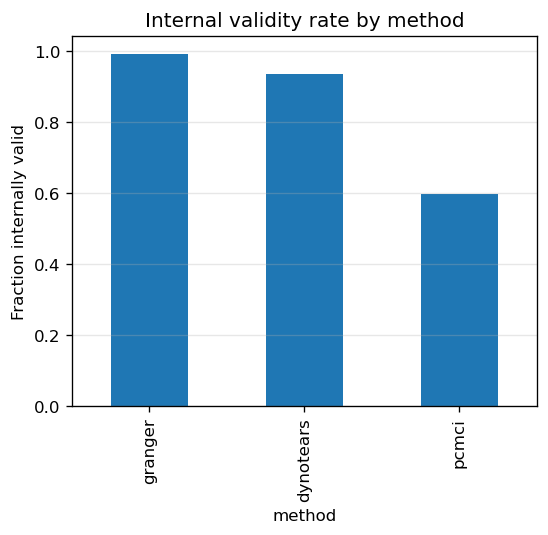

In [210]:
success_rates = (
    df_trial.groupby("method")["internal_valid"]
    .mean()
    .sort_values(ascending=False)
)

print("\nSuccess rates:")
print(success_rates)

plt.figure(figsize=(5,4))
success_rates.plot(kind="bar")
plt.ylabel("Fraction internally valid")
plt.title("Internal validity rate by method")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [211]:
df_valid = df_trial[df_trial["internal_valid"]].copy()

print("Valid runs:", len(df_valid))

Valid runs: 2525


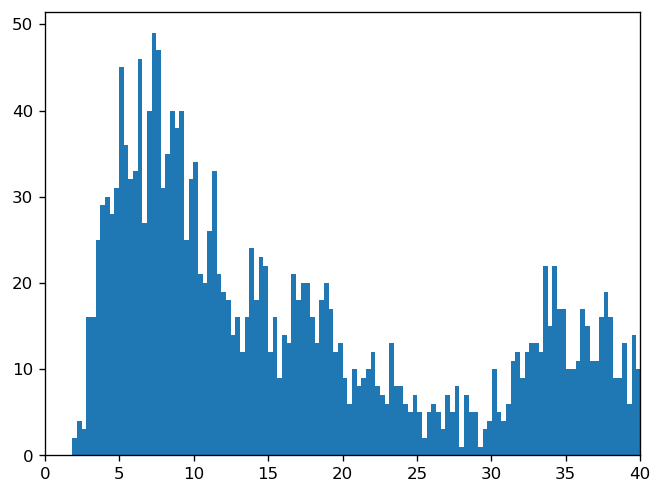

In [212]:
plt.hist(df_valid['mean_origin_distance'],bins=200)
plt.xlim(0,40)
plt.show()

In [213]:
# df_valid = df_valid[df_valid['radius']>=4]
# df_valid = df_valid[df_valid['lambda_a']<=0.1]
# df_valid = df_valid[df_valid['l1_ratio']<=0.25]
# df_valid = df_valid[df_valid['alpha']<4]
# df_valid = df_valid[df_valid['box_size']<30]
# df_valid = df_valid[df_valid['score_mode']=='mean']
# df_valid = df_valid[df_valid['mean_origin_distance']<40]
# df_valid = df_valid[df_valid['mean_parent2_frac']<0.4]
print("Valid runs:", len(df_valid))

Valid runs: 2525


In [214]:
cat_params = ["timewindow", "min_samples_dbscan"]


In [215]:
df_valid

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_failed,track3_mean_distance,track3_origin_distance,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac,internal_valid
0,dynotears,138,3,0,31.0,31,2.305204,3.373177,2.846643,0.0,...,0,3.373177,4.747485,0.0,63.348962,62.161642,2.111632,0.000000,0.967742,True
1,dynotears,539,3,0,31.0,31,2.318836,3.259864,3.033963,0.0,...,0,1.206919,1.236679,0.0,61.580931,58.447098,2.052698,0.000000,0.967742,True
2,dynotears,115,3,0,31.0,31,2.352662,3.252418,3.292413,0.0,...,0,1.702950,1.264148,0.0,62.028656,57.561838,2.067622,0.000000,0.967742,True
3,dynotears,924,3,0,31.0,31,2.412567,3.454657,3.013619,0.0,...,0,1.205330,2.480147,0.0,60.228430,56.998498,2.007614,0.000000,0.967742,True
4,dynotears,512,3,0,31.0,31,2.432494,3.194051,3.588090,0.0,...,0,1.667613,2.982296,0.0,61.567481,57.389923,2.052249,0.000000,0.967742,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,pcmci,690,3,0,31.0,31,29.175826,41.363720,55.326529,0.0,...,0,41.363720,63.948691,0.0,88.185280,6.895251,2.939509,0.066667,0.354839,True
2996,pcmci,960,3,0,31.0,31,29.517802,30.950618,64.507224,0.0,...,0,28.163814,55.537331,0.0,70.402982,5.213539,2.346766,0.000000,0.516129,True
2997,pcmci,924,3,0,31.0,31,29.557774,37.276980,63.542048,0.0,...,0,18.805023,36.841133,0.0,37.122396,28.332178,1.237413,0.000000,0.516129,True
2998,pcmci,78,3,0,31.0,31,29.733857,35.638376,57.733050,0.0,...,0,26.709153,58.047734,0.0,80.558385,31.784778,2.685279,0.000000,0.419355,True


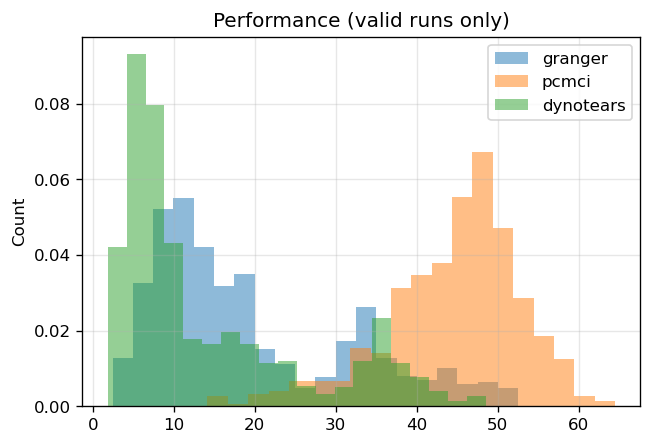

In [216]:
plt.figure(figsize=(6,4))

for method in ["granger", "pcmci", "dynotears"]:
    sub = df_valid[df_valid["method"] == method]
    plt.hist(sub["mean_origin_distance"], bins=20, alpha=0.5, label=method,density=True)

plt.ylabel("Count")
plt.title("Performance (valid runs only)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

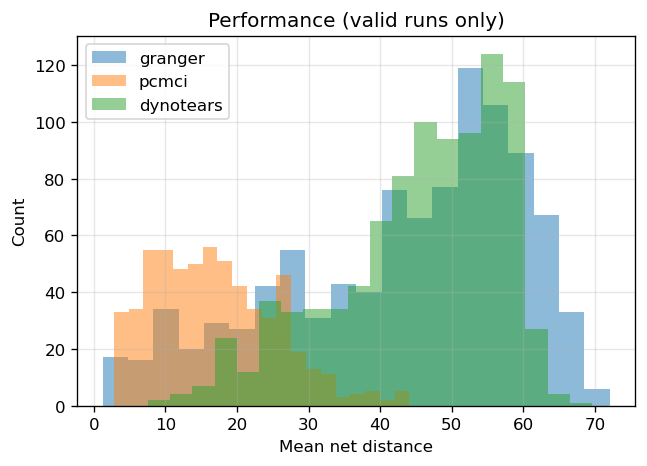

In [217]:
plt.figure(figsize=(6,4))

for method in ["granger", "pcmci", "dynotears"]:
    sub = df_valid[df_valid["method"] == method]
    plt.hist(sub["mean_net_displacement"], bins=20, alpha=0.5, label=method)

plt.xlabel("Mean net distance")
plt.ylabel("Count")
plt.title("Performance (valid runs only)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

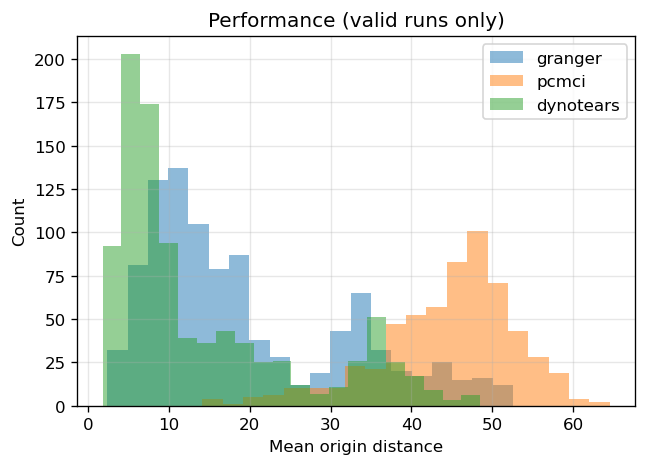

In [218]:
plt.figure(figsize=(6,4))

for method in ["granger", "pcmci", "dynotears"]:
    sub = df_valid[df_valid["method"] == method]
    plt.hist(sub["mean_origin_distance"], bins=20, alpha=0.5, label=method)

plt.xlabel("Mean origin distance")
plt.ylabel("Count")
plt.title("Performance (valid runs only)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

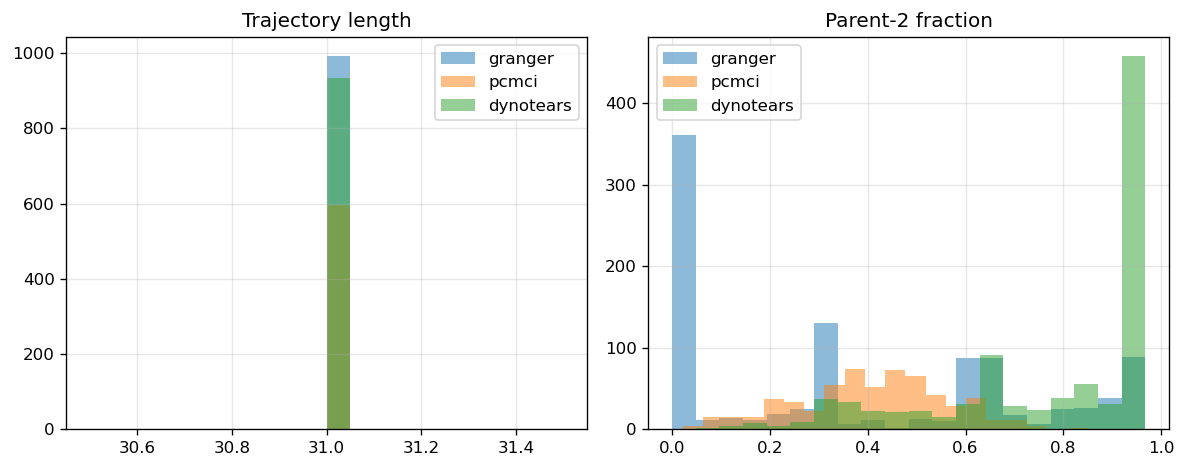

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

for method in ["granger", "pcmci", "dynotears"]:
    sub = df_valid[df_valid["method"] == method]

    axes[0].hist(sub["mean_raw_len"], bins=20, alpha=0.5, label=method)
    axes[1].hist(sub["mean_parent2_frac"], bins=20, alpha=0.5, label=method)

axes[0].set_title("Trajectory length")
axes[1].set_title("Parent-2 fraction")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [220]:
df_valid.keys()

Index(['method', 'trial_id', 'n_tracks', 'n_failed', 'mean_raw_len',
       'min_raw_len', 'mean_distance', 'max_distance', 'mean_origin_distance',
       'mean_event_distance', 'mean_path_length', 'mean_net_displacement',
       'mean_step', 'mean_stagnant_frac', 'mean_parent2_frac', 'elapsed_sec',
       'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan',
       'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule',
       'beta_softmax', 'lambda_a', 'l1_ratio', 'dependence_threshold',
       'max_iter', 'fit_intercept', 'refit_ridge', 'ridge_alpha', 'pc_alpha',
       'graph_p_threshold', 'cond_ind_test_name', 'fdr_method',
       'track1_raw_len', 'track1_failed', 'track1_mean_distance',
       'track1_origin_distance', 'track1_event_distance', 'track1_path_length',
       'track1_net_displacement', 'track1_mean_step', 'track1_stagnant_frac',
       'track1_parent2_frac', 'track2_raw_len', 'track2_failed',
       'track2_mean_distance', 'track2_ori

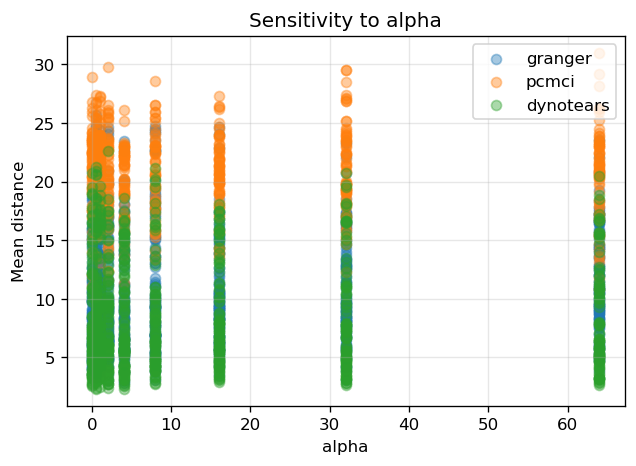

In [221]:
var = "alpha"

plt.figure(figsize=(6,4))

for method in ["granger", "pcmci", "dynotears"]:
    sub = df_valid[df_valid["method"] == method]

    plt.scatter(
        sub[var],
        sub["mean_distance"],
        alpha=0.4,
        label=method
    )

plt.xlabel(var)
plt.ylabel("Mean distance")
plt.title(f"Sensitivity to {var}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [222]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def add_boxes(ax, centers, box_size, color, alpha=0.14, lw=1.1, zorder=2):
    half = box_size / 2.0
    for yc, xc in centers:
        rect = Rectangle(
            (xc - half, yc - half),
            box_size,
            box_size,
            fill=False,
            edgecolor=color,
            linewidth=lw,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(rect)


def _to_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=float)


def plot_trial_trajectories(
    trial_row,
    df_search_traj,
    track_specs,
    A,
    xs,
    ys,
    T,
    contour_level=0.6,
    extent=(0, 200, 0, 200),
    figsize=(10.5, 8),
    n_truth_plot=24,
    box_stride=2,
):
    """
    Plot the 3 synthetic truth trajectories and the recovered trajectories
    for one selected trial row from df_search_trial.

    Parameters
    ----------
    trial_row : pd.Series
        One row from df_search_trial, e.g. df_search_trial.iloc[0]
    df_search_traj : pd.DataFrame
        Trajectory archive with raw centers/parents
    track_specs : list of dict
        Synthetic truth definitions
    A : np.ndarray
        Parent field used for contours, shape (T, NY, NX)
    xs, ys : 1D arrays
        Grid coordinates
    T : int
        Number of timesteps
    n_truth_plot : int
        Number of truth snapshots/contours to display
    box_stride : int
        Plot every `box_stride`-th box to reduce clutter
    """
    method = trial_row["method"]
    trial_id = trial_row["trial_id"]
    box_size = float(trial_row["box_size"])

    sub = df_search_traj[
        (df_search_traj["method"] == method) &
        (df_search_traj["trial_id"] == trial_id)
    ].copy()

    if len(sub) == 0:
        raise ValueError(f"No trajectories found for method={method}, trial_id={trial_id}")

    # determine max recovered trajectory length across the 3 tracks
    lengths = []
    for _, r in sub.iterrows():
        centers = _to_array(r["centers_raw"])
        lengths.append(len(centers))
    n_back = max(lengths) if len(lengths) > 0 else 1

    truth_idx = np.linspace(T - n_back, T - 1, min(n_truth_plot, n_back), dtype=int)
    truth_idx = np.unique(truth_idx)

    fig, ax = plt.subplots(figsize=figsize)

    # --------------------------------------------------
    # 1) contours of A
    # --------------------------------------------------
    for t in truth_idx:
        ax.contour(
            xs,
            ys,
            A[t],
            levels=[contour_level],
            colors=["0.35"],
            linewidths=1.0,
            alpha=0.6,
            zorder=1,
        )

    # --------------------------------------------------
    # 2) true trajectories + event markers
    # --------------------------------------------------
    for k, spec in enumerate(track_specs, start=1):
        truth = np.asarray(spec["centers"], dtype=float)
        event_y, event_x = spec["event"]

        ax.plot(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            "--",
            color="black",
            linewidth=1.9,
            zorder=4,
            label="True trajectory" if k == 1 else None,
        )

        ax.scatter(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            s=18,
            color="black",
            zorder=5,
        )

        ax.plot(
            event_x,
            event_y,
            marker="X",
            markersize=12,
            color="red",
            markeredgecolor="black",
            zorder=10,
            label="Event" if k == 1 else None,
        )

        ax.text(
            event_x + 2.5,
            event_y + 2.5,
            f"{k}",
            fontsize=10,
            weight="bold",
            color="black",
            zorder=11,
        )

    # --------------------------------------------------
    # 3) recovered trajectories for this trial
    # --------------------------------------------------
    color = {
        "granger": "tab:blue",
        "pcmci": "tab:green",
        "dynotears": "tab:orange",
    }.get(method, "tab:purple")

    label_map = {
        "granger": "Granger",
        "pcmci": "PCMCI",
        "dynotears": "Dynotears",
    }
    method_label = label_map.get(method, str(method))

    shown_label = False

    for spec in track_specs:
        r = sub[sub["track_name"] == spec["name"]]
        if len(r) == 0:
            continue

        r = r.iloc[0]
        centers = _to_array(r["centers_raw"])

        centers_for_boxes = centers[::box_stride] if box_stride > 1 else centers

        add_boxes(
            ax,
            centers_for_boxes,
            box_size=box_size,
            color=color,
            alpha=0.14,
            lw=1.0,
            zorder=2,
        )

        ax.plot(
            centers[:, 1],
            centers[:, 0],
            "-",
            color=color,
            linewidth=2.0,
            alpha=0.55,
            zorder=6,
            label=method_label if not shown_label else None,
        )

        ax.plot(
            centers[0, 1],
            centers[0, 0],
            marker="s",
            markersize=7,
            color=color,
            zorder=7,
        )

        ax.plot(
            centers[-1, 1],
            centers[-1, 0],
            marker="*",
            markersize=12,
            color=color,
            zorder=8,
        )

        shown_label = True

    # --------------------------------------------------
    # 4) formatting
    # --------------------------------------------------
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.22, linewidth=0.5)

    title = (
        f"TraCE-ST trajectories | method={method}, trial_id={trial_id}\n"
        f"box={trial_row['box_size']}, radius={trial_row['radius']}, "
        f"timewindow={trial_row['timewindow']}, eps={trial_row['eps_dbscan']}"
    )
    ax.set_title(title, fontsize=12)

    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

In [223]:
best_runs = (
    df_valid.sort_values("mean_distance")
    .groupby("method")
    .head(1)
)

best_runs

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_failed,track3_mean_distance,track3_origin_distance,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac,internal_valid
0,dynotears,138,3,0,31.0,31,2.305204,3.373177,2.846643,0.0,...,0,3.373177,4.747485,0.0,63.348962,62.161642,2.111632,0.0,0.967742,True
16,granger,467,3,0,31.0,31,2.805872,3.022833,3.943691,0.0,...,0,3.022833,6.572593,0.0,64.397672,56.655474,2.146589,0.0,0.000000,True
1269,pcmci,86,3,0,31.0,31,10.207460,11.609133,18.289705,0.0,...,0,8.937892,12.256591,0.0,84.922023,49.034069,2.830734,0.0,0.064516,True


In [224]:
def pick_quantile(df, q):
    return df.sort_values("mean_origin_distance").iloc[int(len(df)*q)]

rows = []

for method in ["granger", "pcmci", "dynotears"]:
    sub = df_valid[df_valid["method"] == method]
    if len(sub) < 3:
        continue

    rows.append(pick_quantile(sub, 0.1))
    rows.append(pick_quantile(sub, 0.5))
    rows.append(pick_quantile(sub, 0.9))

df_repr = pd.DataFrame(rows)
df_repr

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_failed,track3_mean_distance,track3_origin_distance,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac,internal_valid
324,granger,487,3,0,31.0,31,4.850781,8.405322,7.128785,0.0,...,0,4.391630,7.727868,0.0,67.495148,66.130885,2.249838,0.000000,0.000000,True
1342,granger,736,3,0,31.0,31,10.868595,13.559769,15.316640,0.0,...,0,13.559769,16.028357,0.0,80.475558,74.504387,2.682519,0.000000,0.000000,True
1919,granger,850,3,0,31.0,31,16.949955,18.739502,37.824481,0.0,...,0,14.720417,34.701572,0.0,26.085742,24.099976,0.869525,0.733333,0.000000,True
2036,pcmci,122,3,0,31.0,31,17.958447,22.180662,33.256117,0.0,...,0,22.180662,44.249943,0.0,37.964755,18.052513,1.265492,0.266667,0.354839,True
2360,pcmci,54,3,0,31.0,31,21.028264,24.289226,45.937415,0.0,...,0,19.233368,42.239026,0.0,18.600456,17.769098,0.620015,0.633333,0.258065,True
2727,pcmci,628,3,0,31.0,31,23.883129,27.830536,53.846548,0.0,...,0,17.821091,34.192328,0.0,32.609737,29.164546,1.086991,0.000000,0.000000,True
62,dynotears,658,3,0,31.0,31,3.235708,3.593976,4.200464,0.0,...,0,3.593976,5.754574,0.0,64.908304,63.976642,2.163610,0.000000,0.967742,True
603,dynotears,35,3,0,31.0,31,6.109923,6.500854,8.790227,0.0,...,0,5.436648,7.950374,0.0,68.579580,64.472342,2.285986,0.000000,0.935484,True
1811,dynotears,248,3,0,31.0,31,16.058022,22.988809,35.089915,0.0,...,0,4.300131,8.600261,0.0,67.082039,67.082039,2.236068,0.000000,0.000000,True


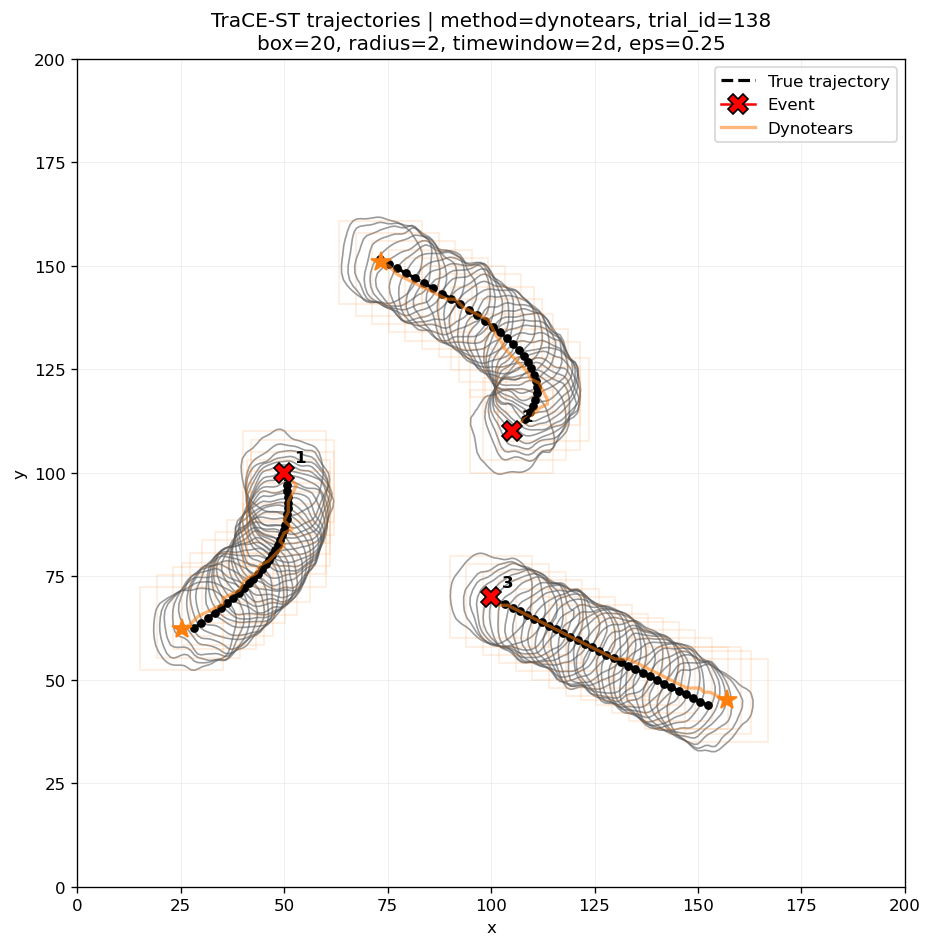

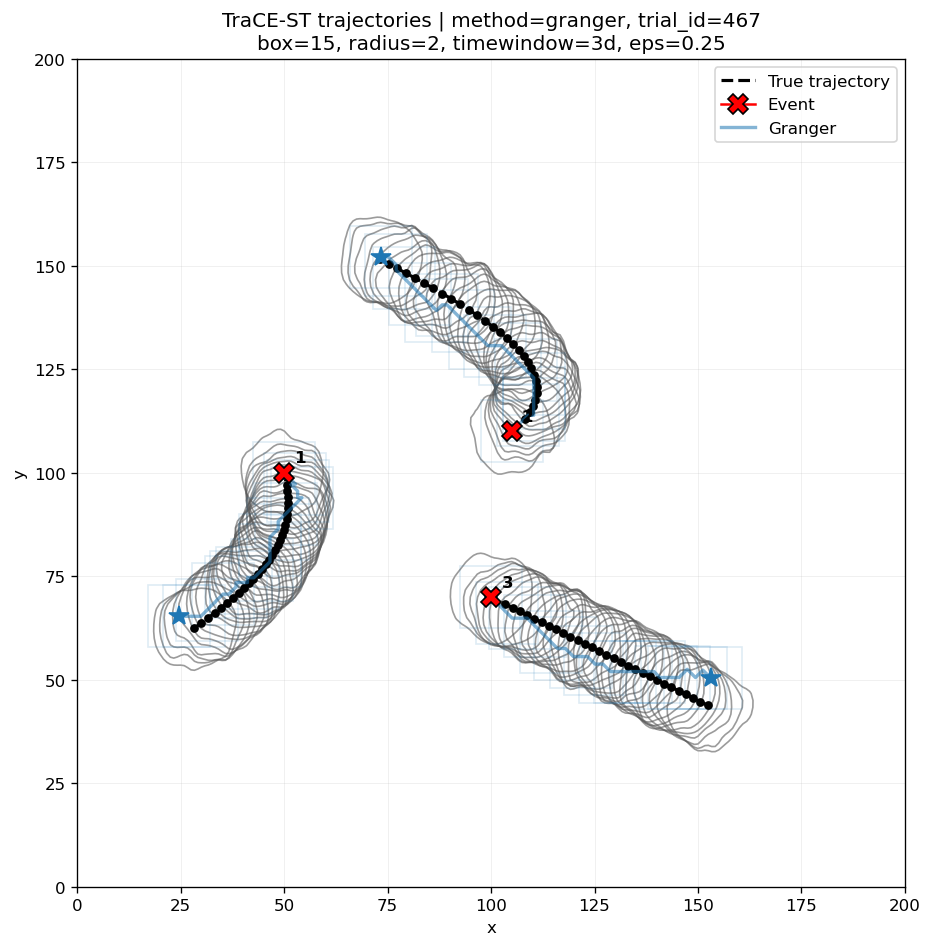

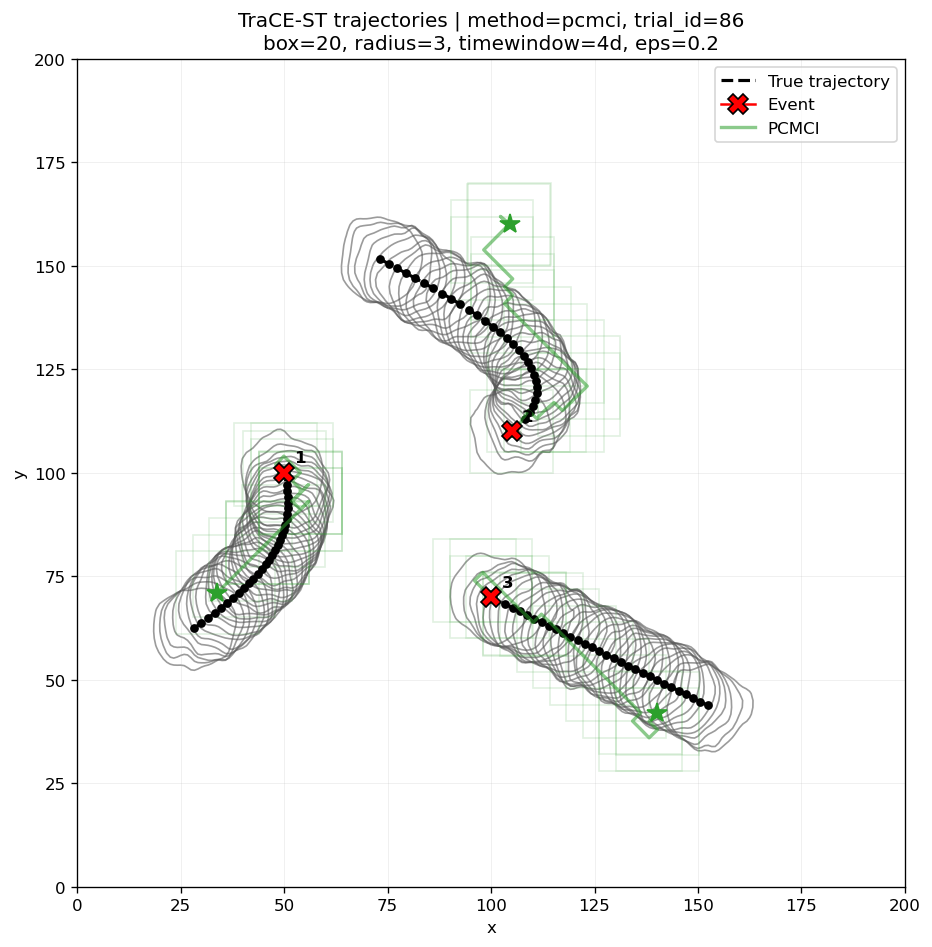

In [225]:
for _, row in best_runs.iterrows():
    plot_trial_trajectories(
        trial_row=row,
        df_search_traj=df_traj,
        track_specs=track_specs,   # MUST exist in this notebook
        A=A,                       # MUST exist
        xs=xs,
        ys=ys,
        T=T,
        n_truth_plot=30
)

In [226]:
def median_error_run(df, method=None):
    sub = df.copy()
    if method is not None:
        sub = sub[sub["method"] == method].copy()

    sub = sub.dropna(subset=["mean_distance"]).sort_values("mean_distance")
    if len(sub) == 0:
        return None

    return sub.iloc[len(sub) // 2]


In [227]:
row_repr_granger = median_error_run(df_valid, method="granger")
row_repr_pcmci = median_error_run(df_valid, method="pcmci")
row_repr_dyno = median_error_run(df_valid, method="dynotears")


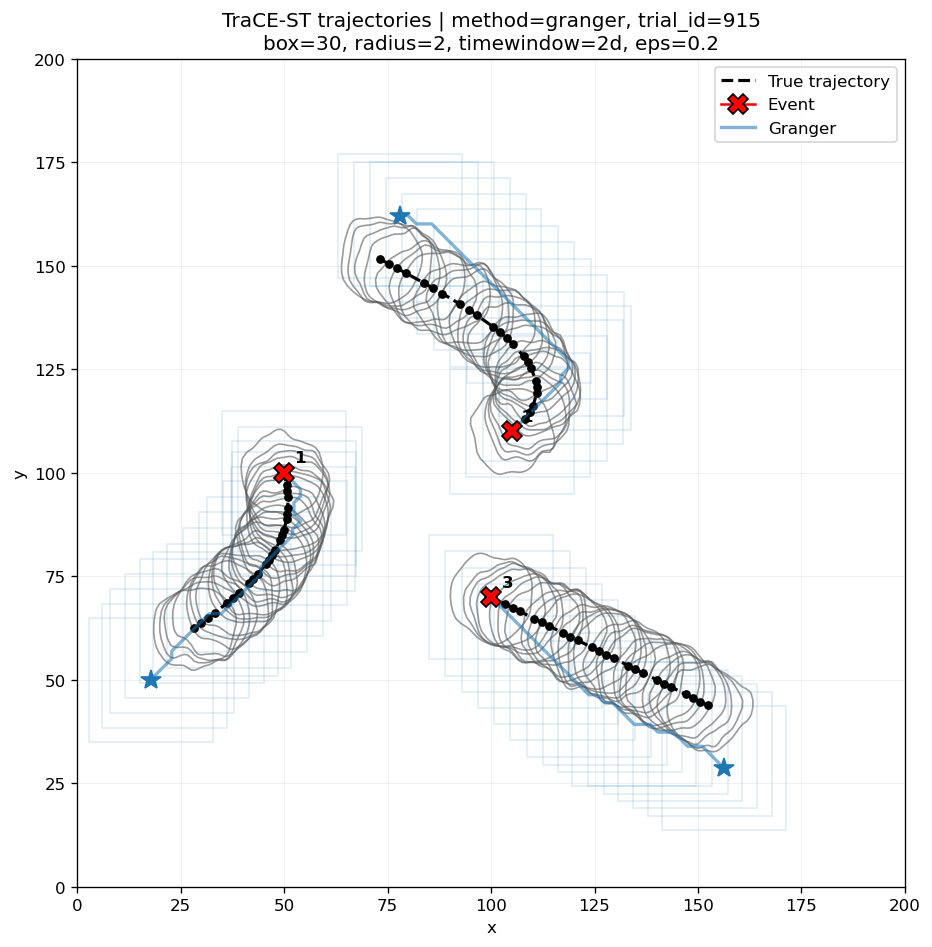

In [228]:
plot_trial_trajectories(
    trial_row=row_repr_granger,
    df_search_traj=df_traj,
    track_specs=track_specs,
    A=A,
    xs=xs,
    ys=ys,
    T=T,
)

In [229]:
import ast
import numpy as np
import matplotlib.pyplot as plt


def _to_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=float)


def _to_int_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=int)


def _pad_or_truncate_centers(centers, target_len):
    centers = np.asarray(centers, dtype=float)
    if len(centers) == 0:
        return None
    if len(centers) < target_len:
        centers = np.vstack([
            centers,
            np.repeat(centers[-1:, :], target_len - len(centers), axis=0)
        ])
    else:
        centers = centers[:target_len]
    return centers


def plot_valid_trajectories_ensemble(
    df_valid_method,
    df_search_traj,
    track_specs,
    A,
    xs,
    ys,
    T,
    method=None,
    contour_level=0.6,
    extent=(0, 200, 0, 200),
    figsize=(10.5, 8),
    traj_alpha=0.10,
    traj_lw=1.1,
    mean_lw=3.0,
    show_mean=True,
    max_runs=None,
    n_truth_plot=31,
    target_len=31,
    show_parent2=True,
    parent2_size=18,
    parent2_alpha=0.65,
):
    """
    Plot all internally valid trajectories for one method as an ensemble.
    """

    dfv = df_valid_method.copy()

    if method is None:
        methods = dfv["method"].dropna().unique()
        if len(methods) != 1:
            raise ValueError("Please pass `method=` explicitly if df_valid_method has multiple methods.")
        method = methods[0]

    dfv = dfv[dfv["method"] == method].copy()
    if len(dfv) == 0:
        raise ValueError(f"No valid runs found for method={method}")

    if max_runs is not None and len(dfv) > max_runs:
        dfv = dfv.iloc[:max_runs].copy()

    color = {
        "granger": "tab:blue",
        "pcmci": "tab:green",
        "dynotears": "tab:orange",
    }.get(method, "tab:purple")

    label_map = {
        "granger": "Elastic-Net",
        "pcmci": "PCMCI",
        "dynotears": "DYNOTEARS",
    }
    method_label = label_map.get(method, str(method))

    trial_ids = set(dfv["trial_id"].tolist())

    sub_traj = df_search_traj[
        (df_search_traj["method"] == method) &
        (df_search_traj["trial_id"].isin(trial_ids))
    ].copy()

    if len(sub_traj) == 0:
        raise ValueError(f"No trajectories found for method={method} and selected valid runs")

    lengths = []
    for _, r in sub_traj.iterrows():
        centers = _to_array(r["centers_raw"])
        lengths.append(len(centers))
    n_back = max(lengths) if len(lengths) > 0 else 1

    truth_idx = np.linspace(T - n_back, T - 1, min(n_truth_plot, n_back), dtype=int)
    truth_idx = np.unique(truth_idx)

    fig, ax = plt.subplots(figsize=figsize)

    # 1) contours of A
    for t in truth_idx:
        ax.contour(
            xs,
            ys,
            A[t],
            levels=[contour_level],
            colors=["0.35"],
            linewidths=1.0,
            alpha=0.6,
            zorder=1,
        )

    # 2) true trajectories + event markers
    for k, spec in enumerate(track_specs, start=1):
        truth = np.asarray(spec["centers"], dtype=float)
        event_y, event_x = spec["event"]

        ax.plot(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            "--",
            color="black",
            linewidth=2.0,
            zorder=5,
            label="True trajectory" if k == 1 else None,
        )

        ax.scatter(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            s=16,
            color="black",
            zorder=6,
        )

        ax.plot(
            event_x,
            event_y,
            marker="X",
            markersize=12,
            color="red",
            markeredgecolor="black",
            zorder=10,
            label="Event" if k == 1 else None,
        )

        ax.text(
            event_x + 2.5,
            event_y + 2.5,
            f"{k}",
            fontsize=10,
            weight="bold",
            color="black",
            zorder=11,
        )

    # 3) all valid recovered trajectories
    shown_label = False
    shown_parent2_label = False

    for spec in track_specs:
        track_name = spec["name"]
        sub_track = sub_traj[sub_traj["track_name"] == track_name].copy()

        if len(sub_track) == 0:
            continue

        aligned_centers = []

        for _, r in sub_track.iterrows():
            centers = _to_array(r["centers_raw"])
            if len(centers) == 0:
                continue

            ax.plot(
                centers[:, 1],
                centers[:, 0],
                "-",
                color=color,
                linewidth=traj_lw,
                alpha=traj_alpha,
                zorder=3,
                label=method_label if not shown_label else None,
            )

            ax.plot(
                centers[0, 1],
                centers[0, 0],
                marker="s",
                markersize=4.5,
                color=color,
                alpha=0.25,
                zorder=4,
            )

            ax.plot(
                centers[-1, 1],
                centers[-1, 0],
                marker="*",
                markersize=7,
                color=color,
                alpha=0.35,
                zorder=4,
            )

            if show_parent2 and "parents_raw" in r and r["parents_raw"] is not None:
                parents = _to_int_array(r["parents_raw"])

                n = min(len(centers), len(parents))
                if n > 0:
                    centers_p = centers[:n]
                    parents_p = parents[:n]
                    mask2 = parents_p == 2

                    if np.any(mask2):
                        ax.scatter(
                            centers_p[mask2, 1],
                            centers_p[mask2, 0],
                            s=parent2_size,
                            color="red",
                            alpha=parent2_alpha,
                            zorder=7,
                            label="Parent = 2" if not shown_parent2_label else None,
                        )
                        shown_parent2_label = True

            aligned = _pad_or_truncate_centers(centers, target_len)
            if aligned is not None:
                aligned_centers.append(aligned)

            shown_label = True

    # 4) formatting
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.22, linewidth=0.5)

    ax.set_title(
        f"Internally valid {method_label} trajectories (n={len(dfv)})",
        fontsize=12
    )

    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

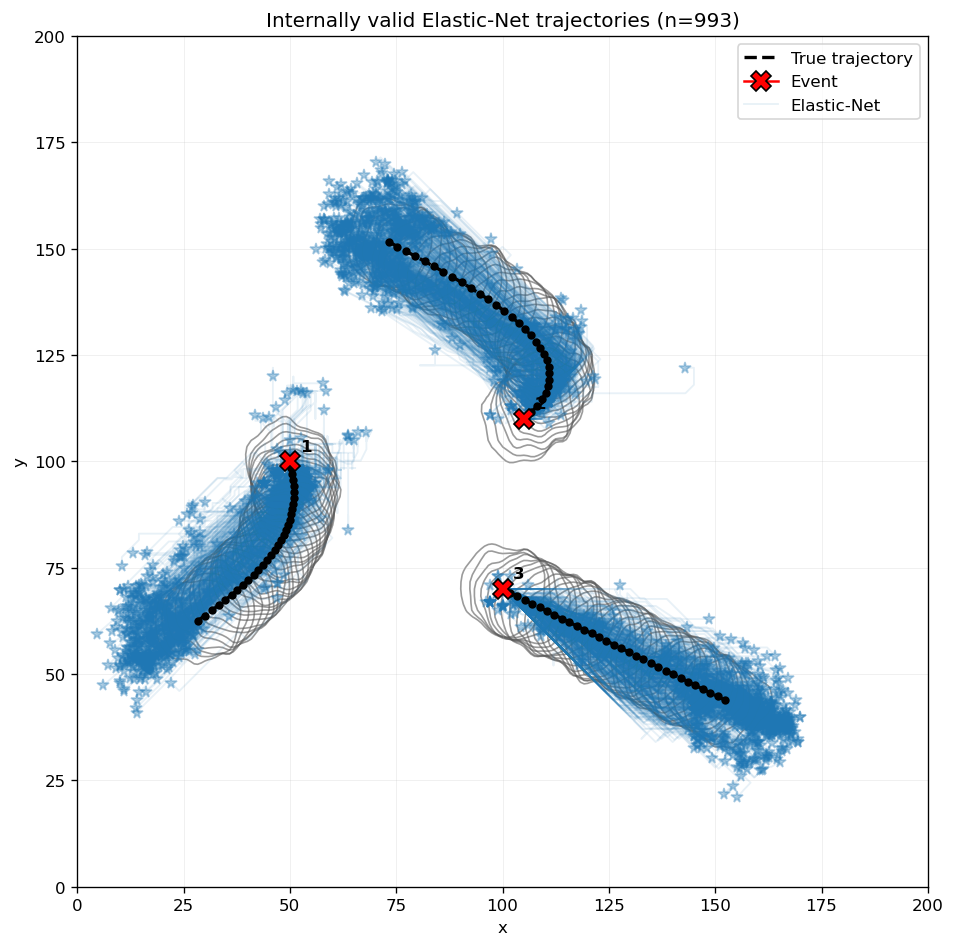

In [231]:
plot_valid_trajectories_ensemble(
    df_valid_method=df_valid[df_valid["method"] == "granger"],
    df_search_traj=df_traj,
    track_specs=track_specs,
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    method="granger",
    show_parent2=False,
    parent2_alpha=0.01,
    parent2_size=10
)

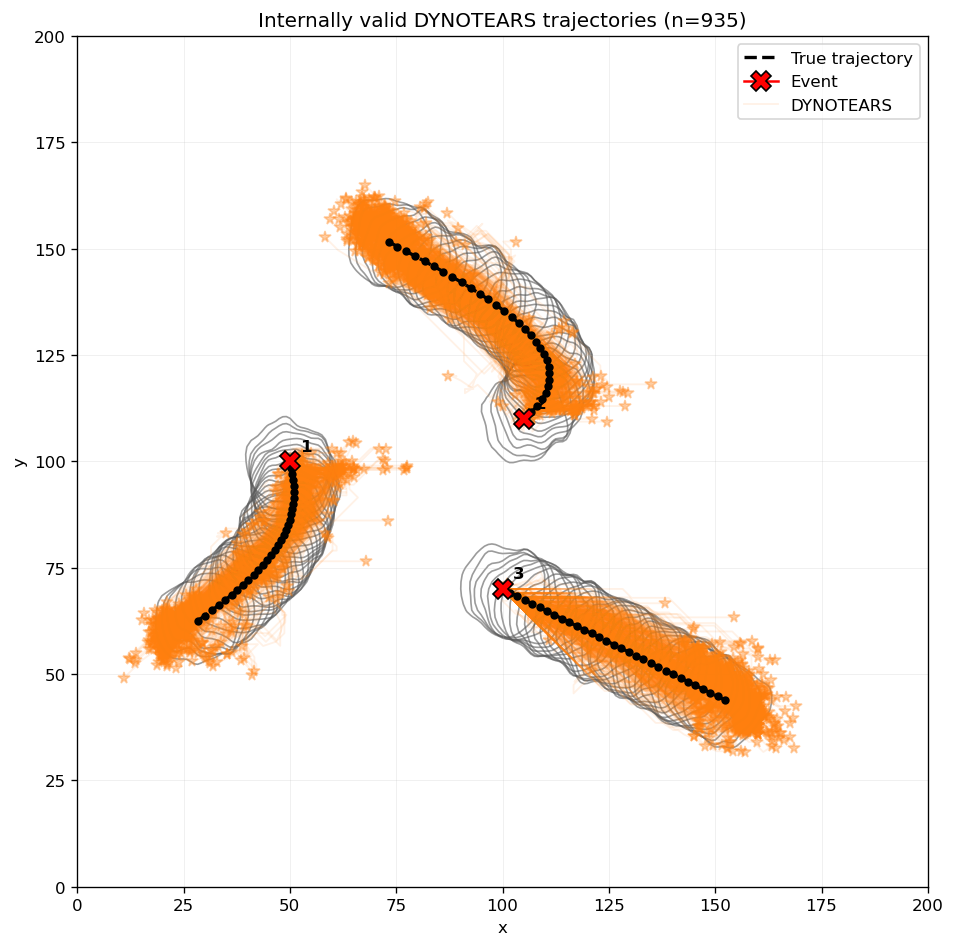

In [232]:
plot_valid_trajectories_ensemble(
    df_valid_method=df_valid[df_valid["method"] == "dynotears"],
    df_search_traj=df_traj,
    track_specs=track_specs,
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    method="dynotears",
    parent2_alpha=0.3,
    parent2_size=10.,
    show_parent2=False,
)

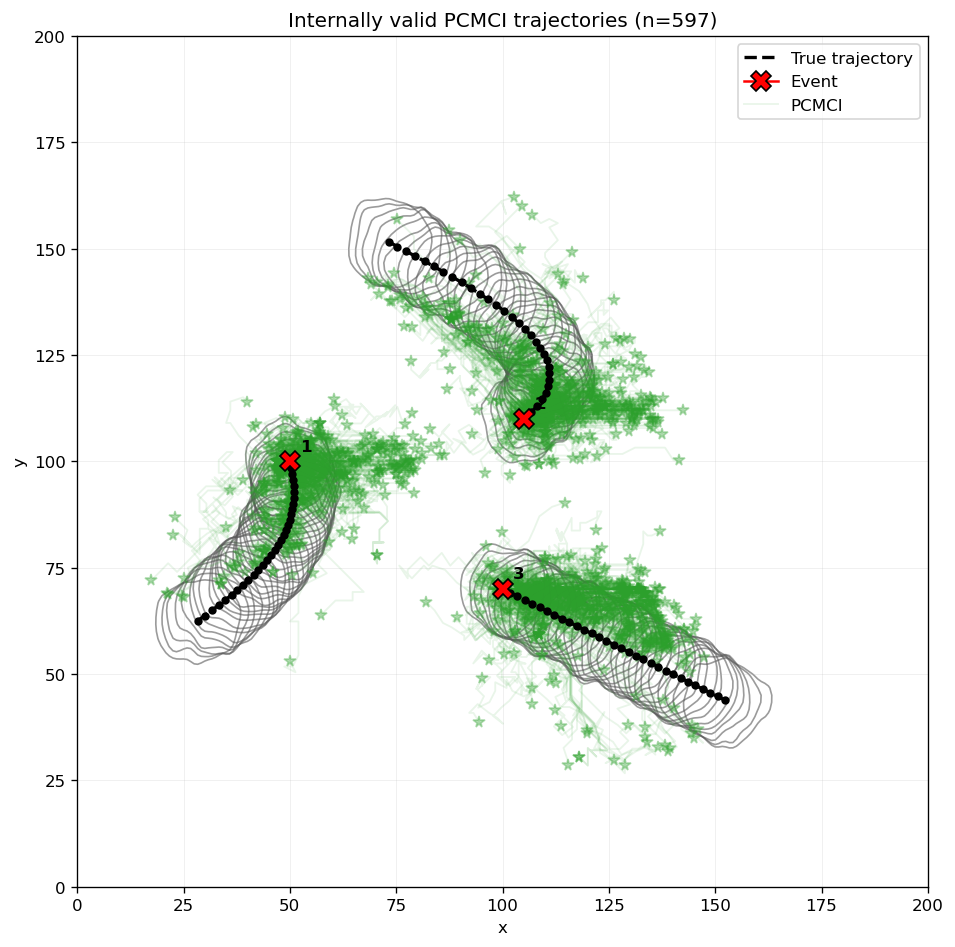

In [233]:
plot_valid_trajectories_ensemble(
    df_valid_method=df_valid[df_valid["method"] == "pcmci"],
    df_search_traj=df_traj,
    track_specs=track_specs,
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    method="pcmci",
    parent2_alpha=0.01,
    parent2_size=10,
    show_parent2=False,
)

(array([ 75., 105., 155.,  36.,  12.,  25.,   4.,   4.,   4.,   7.]),
 array([ 1.10702255,  7.30716681, 13.50731106, 19.70745532, 25.90759958,
        32.10774383, 38.30788809, 44.50803234, 50.7081766 , 56.90832085,
        63.10846511]),
 <BarContainer object of 10 artists>)

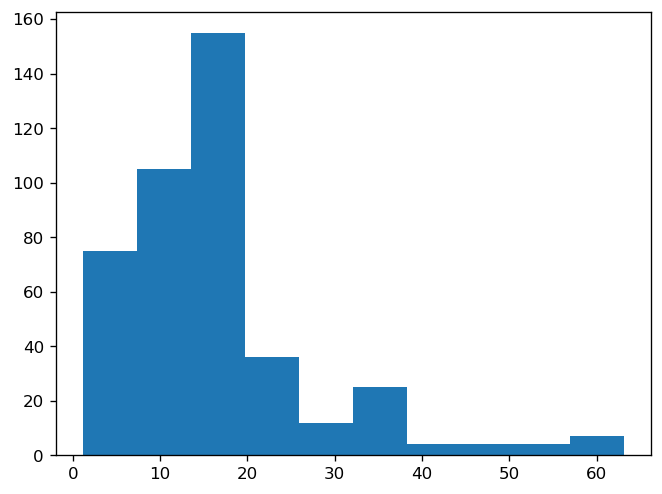

In [234]:
plt.hist(df.track1_origin_distance)

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = df_valid[df_valid['method']=='granger']
# define groups
# df["good_parent"] = (df["mean_parent2_frac"] < 0.3)
# df["good_parent"] = (df["track2_net_displacement"] > 55)
df["good_parent"] = (df["track1_origin_distance"] < 30)
# df["good_parent"] = (df["mean_parent2_frac"] < 0.3)

# optional: cleaner labels
df["group"] = df["good_parent"].map({True: "good", False: "bad"})

/glade/derecho/scratch/jhayron/tmp/ipykernel_101819/980597155.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["good_parent"] = (df["track1_origin_distance"] < 30)
/glade/derecho/scratch/jhayron/tmp/ipykernel_101819/980597155.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["group"] = df["good_parent"].map({True: "good", False: "bad"})


/glade/derecho/scratch/jhayron/tmp/ipykernel_101819/1215089539.py:38: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/glade/derecho/scratch/jhayron/tmp/ipykernel_101819/1215089539.py:38: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/glade/derecho/scratch/jhayron/tmp/ipykernel_101819/1215089539.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/glade/derecho/scratch/jhayron/tmp/ipykernel_101819/1215089539.py:38: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/glade/derecho/scratch/jhayron/tmp/ipykernel_101819/1215089539.py:38: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `war

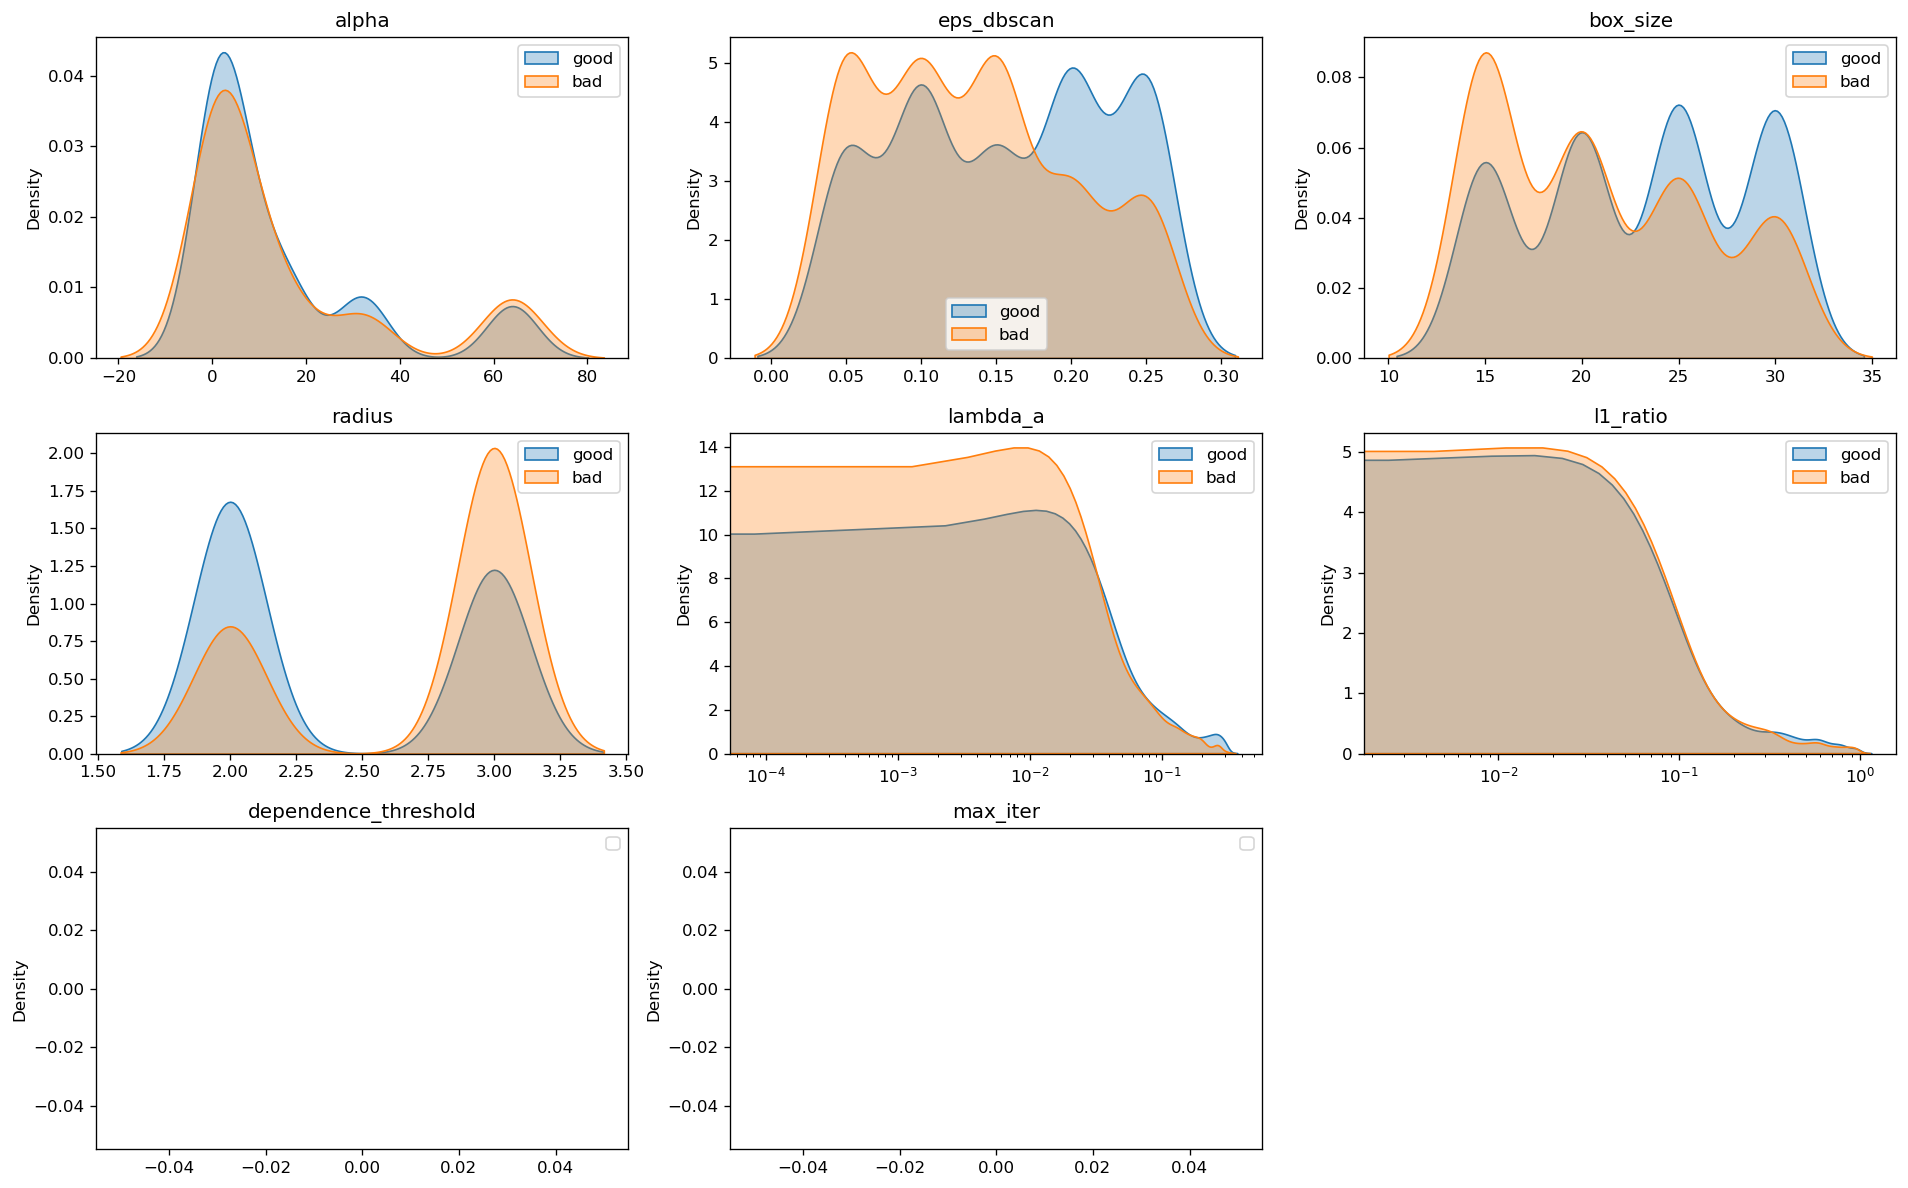

In [236]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cont_params = [
    "alpha",
    "eps_dbscan",
    "box_size",
    "radius",
    "lambda_a",
    "l1_ratio",
    "dependence_threshold",
    "max_iter",
]

# parameters that should be shown in log scale
log_params = {"lambda_a", "l1_ratio"}

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.ravel()

for i, param in enumerate(cont_params):
    ax = axes[i]

    for label, color in zip(["good", "bad"], ["tab:blue", "tab:red"]):
        sub = df[df["group"] == label]

        x = sub[param].values.astype(float)

        # remove non-positive values for log plots
        if param in log_params:
            mask = x > 0
            x = x[mask]

        if len(x) == 0:
            continue

        sns.kdeplot(
            x=x,
            ax=ax,
            fill=True,
            alpha=0.3,
            label=label,
        )

    if param in log_params:
        ax.set_xscale("log")

    ax.set_title(param)
    ax.legend()

# remove empty panels if any
for j in range(len(cont_params), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Figure size 720x480 with 0 Axes>

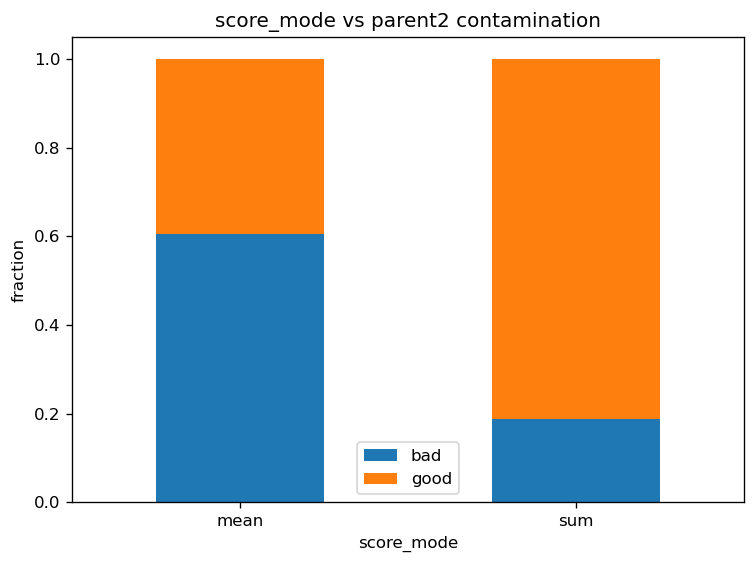

<Figure size 720x480 with 0 Axes>

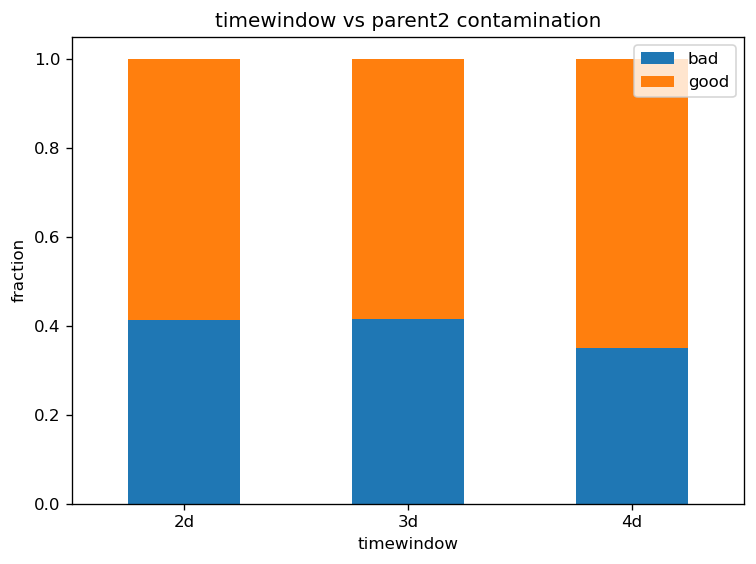

<Figure size 720x480 with 0 Axes>

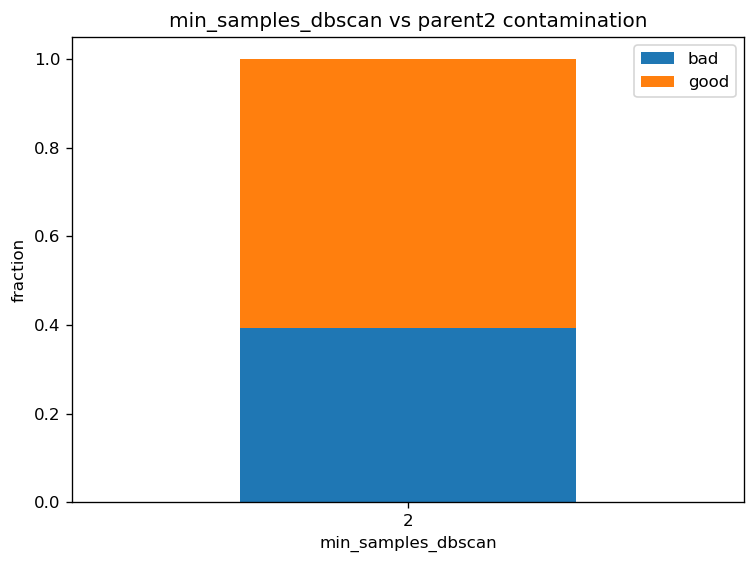

In [237]:
cat_params = ["score_mode", "timewindow", "min_samples_dbscan"]

for param in cat_params:
    plt.figure(figsize=(6,4))
    
    tab = pd.crosstab(df[param], df["group"], normalize="index")
    tab.plot(kind="bar", stacked=True)
    
    plt.title(f"{param} vs parent2 contamination")
    plt.ylabel("fraction")
    plt.xticks(rotation=0)
    plt.legend(title="")
    plt.tight_layout()
    plt.show()